In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("cleaned_statsfinal.csv")

print("Dataset loaded successfully!")
print(df.head())
print("\nShape:", df.shape)

Dataset loaded successfully!
   Unnamed: 0        Date  Q-P1  Q-P2  Q-P3  Q-P4      S-P1      S-P2  \
0           0  2010-06-13  5422  3725   576   907  17187.74  23616.50   
1           1  2010-06-14  7047   779  3578  1574  22338.99   4938.86   
2           2  2010-06-15  1572  2082   595  1145   4983.24  13199.88   
3           3  2010-06-16  5657  2399  3140  1672  17932.69  15209.66   
4           4  2010-06-17  3668  3207  2184   708  11627.56  20332.38   

       S-P3      S-P4  Total_Sales  Total_Quantity  
0   3121.92   6466.91     50393.07           10630  
1  19392.76  11222.62     57893.23           12978  
2   3224.90   8163.85     29571.87            5394  
3  17018.80  11921.36     62082.51           12868  
4  11837.28   5048.04     48845.26            9767  

Shape: (4600, 12)


In [3]:
target = "Total_Sales"

X = df.drop(columns=[target])
y = df[target]

print("Target:", target)
print("Input features:")
print(X.columns.tolist())

Target: Total_Sales
Input features:
['Unnamed: 0', 'Date', 'Q-P1', 'Q-P2', 'Q-P3', 'Q-P4', 'S-P1', 'S-P2', 'S-P3', 'S-P4', 'Total_Quantity']


In [5]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (4600, 4583)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 4583)
Testing data: (920, 4583)


In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [8]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print("Ridge Regression trained successfully!")

Ridge Regression trained successfully!


In [9]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

print("Lasso Regression trained successfully!")

Lasso Regression trained successfully!


In [10]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model  Train R2  Test R2    Train RMSE     Test RMSE
0  Linear Regression       1.0      1.0  5.002132e-09  8.269709e-08
1   Ridge Regression       1.0      1.0  8.601035e-08  1.653975e-07
2   Lasso Regression       1.0      1.0  4.933156e-04  4.823311e-04


In [11]:
results_df["R2 Gap"] = results_df["Train R2"] - results_df["Test R2"]

print(results_df)

               Model  Train R2  Test R2    Train RMSE     Test RMSE  \
0  Linear Regression       1.0      1.0  5.002132e-09  8.269709e-08   
1   Ridge Regression       1.0      1.0  8.601035e-08  1.653975e-07   
2   Lasso Regression       1.0      1.0  4.933156e-04  4.823311e-04   

         R2 Gap  
0  0.000000e+00  
1  0.000000e+00  
2  1.110223e-16  


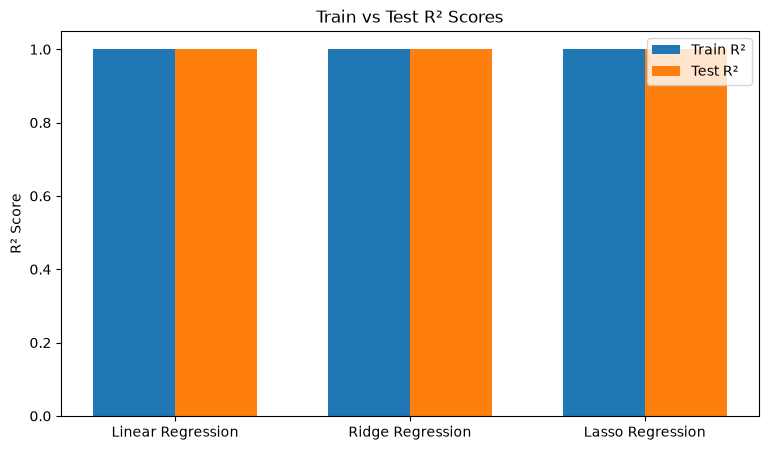

In [12]:
plt.figure(figsize=(9, 5))

x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df["Train R2"], width, label="Train R²")
plt.bar(x + width/2, results_df["Test R2"], width, label="Test R²")

plt.xticks(x, results_df["Model"])
plt.ylabel("R² Score")
plt.title("Train vs Test R² Scores")
plt.legend()
plt.show()

# Day 13 — Model Optimization

## Overfitting and Regularization Analysis

### Baseline Model
Linear Regression was used as the baseline model. Its training and testing performance were compared to determine how well it generalizes to unseen data.

### Ridge Regression
Ridge Regression applies L2 regularization. It reduces the impact of large model coefficients and can help improve generalization.

### Lasso Regression
Lasso Regression applies L1 regularization. It can reduce some coefficients toward zero and can therefore help simplify the model.

### Train vs Test Performance

The train and test R² scores and RMSE values were compared for all three models.

A large difference between training and testing performance can indicate possible overfitting. A smaller difference generally indicates better generalization.

### Model Behavior

- Linear Regression provides the baseline performance.
- Ridge Regression controls coefficient size through regularization.
- Lasso Regression can reduce the influence of less important features.
- The model with the best balance between training and testing performance is preferable for generalization.

### Conclusion

Regularization provides a way to control model complexity and reduce the risk of overfitting. Comparing train and test performance helps determine whether a model generalizes well to unseen data.

In [ ]:
results_df.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")